In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from tqdm import tqdm

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, AutoModelForCausalLM
from datasets import load_dataset
import evaluate
import torch

## 1. Setup

* Configure device
* Load models (T5 small and GPT-2) and tokenizer

In [2]:
# Configure device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

Using device:  cpu


In [3]:
# Define models

t5_model_name = "t5-small"
gpt_model_name = "gpt2"

In [4]:
# Tokenizers

t5_tokenizer = AutoTokenizer.from_pretrained(t5_model_name)

gpt_tokenizer = AutoTokenizer.from_pretrained(gpt_model_name)
gpt_tokenizer.pad_token = gpt_tokenizer.eos_token

In [5]:
# Load models

t5_model = AutoModelForSeq2SeqLM.from_pretrained(t5_model_name)
t5_model.to(device)
t5_model.eval() # evaluation mode (no training)

gpt_model = AutoModelForCausalLM.from_pretrained(gpt_model_name)
gpt_model.to(device)
gpt_model.eval()

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [6]:
# Test T5

text = "summarize: Mamoru Fujisawa, known professionally as Joe Hisaishi, is a Japanese composer, musical director, conductor and pianist, known for over 100 film scores and solo albums dating back to 1981. Hisaishi's music has been known to explore and incorporate different genres, including minimalist, experimental electronic, Western classical, and Japanese classical. He has also worked as a music engraver and arranger."

inputs = t5_tokenizer(text, return_tensors="pt").to(device)
outputs = t5_model.generate(**inputs, max_length=50)
summary = t5_tokenizer.decode(outputs[0], skip_special_tokens=True)

print("Summary from T5:")
print(summary)

Summary from T5:
hisaishi's music has been known to explore and incorporate different genres. he has worked as a music engraver and arranger.


In [7]:
# Test GPT2

text = "summarize: Mamoru Fujisawa, known professionally as Joe Hisaishi, is a Japanese composer, musical director, conductor and pianist, known for over 100 film scores and solo albums dating back to 1981. Hisaishi's music has been known to explore and incorporate different genres, including minimalist, experimental electronic, Western classical, and Japanese classical. He has also worked as a music engraver and arranger."

inputs = gpt_tokenizer(text, return_tensors="pt").to(device)
outputs = gpt_model.generate(**inputs, max_new_tokens=30, do_sample=True, temperature=0.7)
summary = gpt_tokenizer.decode(outputs[0], skip_special_tokens=True)

print("Summary from GPT2:")
print(summary)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Summary from GPT2:
summarize: Mamoru Fujisawa, known professionally as Joe Hisaishi, is a Japanese composer, musical director, conductor and pianist, known for over 100 film scores and solo albums dating back to 1981. Hisaishi's music has been known to explore and incorporate different genres, including minimalist, experimental electronic, Western classical, and Japanese classical. He has also worked as a music engraver and arranger. As a composer he has worked on many albums, including the highly regarded "Dante and Me" "Dante in the Dark," "Dark Side


As expected:
* T5 summarizes the text
* GPT2 continues generating tokens and appending them to the input

## 2. Dataset exploration (CNN/DailyMail)

In [8]:
dataset = load_dataset("cnn_dailymail", "3.0.0")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 287113
    })
    validation: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 13368
    })
    test: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 11490
    })
})


In [9]:
# Inspect

sample = dataset["train"][0]

print("Article:\n")
print(sample["article"])

Article:

LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don't plan to be one of those people who, as soon as they turn 18, suddenly buy themselves a massive sports car collection or something similar," he told an Australian interviewer earlier this month. "I don't think I'll be particularly extravagant. "The things I like buying are things that cost about 10 pounds -- books and CDs and DVDs." At 18, Radcliffe will be able to gamble in a casino, buy a drink in a pub or see the horror film "Hostel: Part II," currently six places below his number one movie on the UK box office chart. Deta

In [10]:
print("Summary:\n")
print(sample["highlights"])

Summary:

Harry Potter star Daniel Radcliffe gets £20M fortune as he turns 18 Monday .
Young actor says he has no plans to fritter his cash away .
Radcliffe's earnings from first five Potter films have been held in trust fund .


In [11]:
# Analysis of the length (# of words) of the texts

article_lengths = []
summary_lengths = []

for i in range(1000):  # just a subset

    article = dataset["train"][i]["article"]
    summary = dataset["train"][i]["highlights"]

    article_lengths.append(len(article.split()))
    summary_lengths.append(len(summary.split()))

In [12]:
article_lengths = np.array(article_lengths)
summary_lengths = np.array(summary_lengths)

print("Article length mean: ", article_lengths.mean())
print("Summary length mean: ", summary_lengths.mean())

print("Article length max length: ", article_lengths.max())
print("Summary length max length: ", summary_lengths.max())

Article length mean:  591.624
Summary length mean:  42.767
Article length max length:  1743
Summary length max length:  66


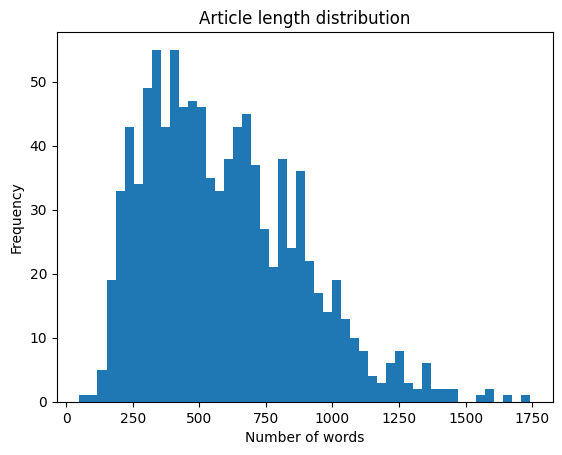

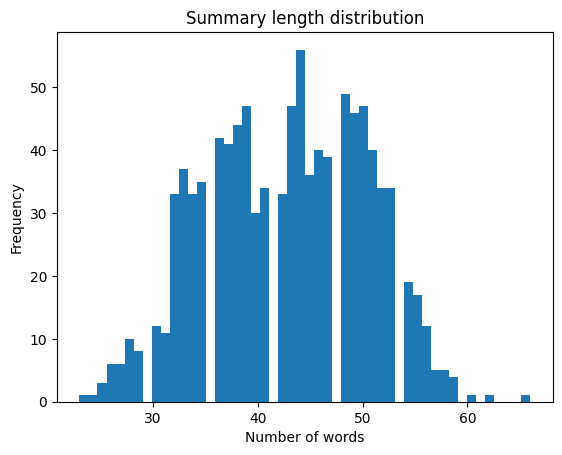

In [13]:
# Distribution of lengths

plt.hist(article_lengths, bins=50)
plt.title("Article length distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

plt.hist(summary_lengths, bins=50)
plt.title("Summary length distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

Of course, article length is on average much bigger than summary lengths, as summaries require to capture only essential information. This can make the summarization task challenging for GPT2, which is not explicitely designed for this task.

In [14]:
# Reduction of the training and validation sets (necessary for modelling locally)

small_train = dataset["train"].select(range(2000))
small_val = dataset["validation"].select(range(500))

## 3. Baseline models (Lead-3 and truncation)

Before using LLMs, I need to evaluate some baseline models. The question is: what's the performance without AI? I consider:
* Baseline 1: I took as summary the first 3 sentences to be compared with the actual highlights.
* Baseline 2: I took as summary the first N tokens to be compared with the actual highlights.

Evaluate ROUGE for both baselines.

In [15]:
train_data = small_train
val_data = small_val

print(len(train_data), len(val_data))

2000 500


In [16]:
# Baseline 1

def lead_3_summary(article):

    sentences = article.split(".")
    first_sentences = sentences[:3]
    summary = ". ".join(first_sentences)

    return summary.strip() + "."

In [17]:
# Test baseline 1

sample = val_data[0]

print("Article: ", sample["article"])
print("\nLead-3 summary: ", lead_3_summary(sample["article"]))
print("\nReference highlights: ", sample["highlights"])

Article:  (CNN)Share, and your gift will be multiplied. That may sound like an esoteric adage, but when Zully Broussard selflessly decided to give one of her kidneys to a stranger, her generosity paired up with big data. It resulted in six patients receiving transplants. That surprised and wowed her. "I thought I was going to help this one person who I don't know, but the fact that so many people can have a life extension, that's pretty big," Broussard told CNN affiliate KGO. She may feel guided in her generosity by a higher power. "Thanks for all the support and prayers," a comment on a Facebook page in her name read. "I know this entire journey is much bigger than all of us. I also know I'm just the messenger." CNN cannot verify the authenticity of the page. But the power that multiplied Broussard's gift was data processing of genetic profiles from donor-recipient pairs. It works on a simple swapping principle but takes it to a much higher level, according to California Pacific Medic

In [18]:
# Baseline 2

def truncate_summary(article, max_words=50):

    words = article.split()
    truncated = words[:max_words]

    return " ".join(truncated)

In [19]:
# Test baseline 2

print("Truncated summary: ", truncate_summary(sample["article"]))

Truncated summary:  (CNN)Share, and your gift will be multiplied. That may sound like an esoteric adage, but when Zully Broussard selflessly decided to give one of her kidneys to a stranger, her generosity paired up with big data. It resulted in six patients receiving transplants. That surprised and wowed her. "I thought


In [20]:
# Evaluate baseline models with ROUGE

rouge = evaluate.load("rouge")

lead3_preds = []
truncate_preds = []
references = []

for i in range(len(val_data)):

    article = val_data[i]["article"]
    reference = val_data[i]["highlights"]

    lead3 = lead_3_summary(article)
    trunc = truncate_summary(article)

    lead3_preds.append(lead3)
    truncate_preds.append(trunc)
    references.append(reference)

In [21]:
lead3_scores = rouge.compute(predictions=lead3_preds, references=references)
truncate_scores = rouge.compute(predictions=truncate_preds, references=references)

print("Lead3 ROUGE: ", lead3_scores)
print("Truncate ROUGE: ", truncate_scores)

Lead3 ROUGE:  {'rouge1': np.float64(0.27414798329862855), 'rouge2': np.float64(0.1059324402856267), 'rougeL': np.float64(0.18821413268510429), 'rougeLsum': np.float64(0.2256387231618835)}
Truncate ROUGE:  {'rouge1': np.float64(0.29290841590638433), 'rouge2': np.float64(0.10959144983295878), 'rougeL': np.float64(0.19971120012903576), 'rougeLsum': np.float64(0.2395324341002176)}


Results for both baseline methods are quite similar.
* ROUGE 1 achieves a discrete value, meaning that there is a discrete overlap of single words.
* However, ROUGE 2 and L are low, meaning that quality and the structure of these summaries are not optimal.

I expect to do better with T5 and GPT.

## 4. T5 Summarization

In [29]:
# Summarization function with T5 using batching

def generate_t5_batch(articles, batch_size=8):

    summaries = []

    for i in tqdm(range(0, len(articles), batch_size), desc="Generating summaries"):

        batch = articles[i:i+batch_size]
        batch_inputs = ["summarize: " + art for art in batch]

        # Tokenization
        inputs = t5_tokenizer(batch_inputs, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)

        # Generation
        outputs = t5_model.generate(**inputs, max_new_tokens=50, num_beams=4)

        # Decode batch
        decoded = t5_tokenizer.batch_decode(outputs, skip_special_tokens=True)

        summaries.extend(decoded)

    return summaries

In [30]:
# Prepare data and generate

articles = [val_data[i]["article"] for i in range(len(val_data))]
references = [val_data[i]["highlights"] for i in range(len(val_data))]

t5_preds = generate_t5_batch(articles)

Generating summaries: 100%|████████████████████████████████████████████████████████████| 63/63 [03:09<00:00,  3.01s/it]


In [32]:
# ROUGE score

t5_scores = rouge.compute(predictions=t5_preds, references=references)
print("ROUGE: ", t5_scores)

ROUGE:  {'rouge1': np.float64(0.2826023575457423), 'rouge2': np.float64(0.10613121693261923), 'rougeL': np.float64(0.21212385238776826), 'rougeLsum': np.float64(0.24197385973889776)}


In [35]:
# Print some results

for i in range(5):

    print(articles[i], "\n")
    print(t5_preds[i], "\n\n")

(CNN)Share, and your gift will be multiplied. That may sound like an esoteric adage, but when Zully Broussard selflessly decided to give one of her kidneys to a stranger, her generosity paired up with big data. It resulted in six patients receiving transplants. That surprised and wowed her. "I thought I was going to help this one person who I don't know, but the fact that so many people can have a life extension, that's pretty big," Broussard told CNN affiliate KGO. She may feel guided in her generosity by a higher power. "Thanks for all the support and prayers," a comment on a Facebook page in her name read. "I know this entire journey is much bigger than all of us. I also know I'm just the messenger." CNN cannot verify the authenticity of the page. But the power that multiplied Broussard's gift was data processing of genetic profiles from donor-recipient pairs. It works on a simple swapping principle but takes it to a much higher level, according to California Pacific Medical Center 

Results of T5 are comparable with those of the baseline models.

## 5. GPT Summarization + Prompt engineering

Since GPT is not meant to make summaries, I need to guide it. I test:
* Zero shot prompting
* Few shots prompting

In [46]:
# Zero shot

def generate_gpt_summary(article, mode="zero"):

    # Prompt zero shot
    if mode == "zero":
        prompt = "Summarize the following text:\n\n" + article + "\n\nSummary:"

    # Prompt few shot
    elif mode == "few":
        prompt = f"""
Text: Deep learning is a subset of machine learning that uses neural networks.
Summary: Deep learning uses neural networks.

Text: {article}
Summary:
"""

    # Tokenization
    inputs = gpt_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(device)

    # Generation
    outputs = gpt_model.generate(**inputs, max_new_tokens=50, do_sample=True, temperature=0.7, top_k=50, top_p=0.9)

    # Decode batch
    generated_text = gpt_tokenizer.decode(outputs[0], skip_special_tokens=True)

    summary = generated_text.split("Summary:")[-1].strip()

    return summary

In [48]:
# Batch processing

def generate_gpt_batch(articles, mode="zero", batch_size=4):

    summaries = []

    for i in range(0, len(articles), batch_size):

        batch = articles[i:i+batch_size]

        for article in batch:
            summary = generate_gpt_summary(article, mode=mode)
            summaries.append(summary)

    return summaries

In [52]:
# Print some results

for i in range(5):

    print("\n\nARTICLE: ", articles[i], "\n")
    print("GPT ZERO: ", gpt_zero_preds[i], "\n")
    print("GPT FEW: ", gpt_few_preds[i], "\n")



ARTICLE:  (CNN)Share, and your gift will be multiplied. That may sound like an esoteric adage, but when Zully Broussard selflessly decided to give one of her kidneys to a stranger, her generosity paired up with big data. It resulted in six patients receiving transplants. That surprised and wowed her. "I thought I was going to help this one person who I don't know, but the fact that so many people can have a life extension, that's pretty big," Broussard told CNN affiliate KGO. She may feel guided in her generosity by a higher power. "Thanks for all the support and prayers," a comment on a Facebook page in her name read. "I know this entire journey is much bigger than all of us. I also know I'm just the messenger." CNN cannot verify the authenticity of the page. But the power that multiplied Broussard's gift was data processing of genetic profiles from donor-recipient pairs. It works on a simple swapping principle but takes it to a much higher level, according to California Pacific Med

GPT-2 Fails to perform summarization in both settings:
* In zero shot it just continue the input generating tokens
* In few shot it often repeating the example instead of generalizing the task

GPT2 fails to follow a specific task.

## 6. Analysis of results

In [54]:
# Comparison

results = {
    "Lead-3": lead3_scores,
    "Truncate": truncate_scores,
    "T5": t5_scores,
    "GPT zero shot": gpt_zero_scores,
    "GPT few shot": gpt_few_scores
}

for model, scores in results.items():
    print(f"\n{model}")
    for metric, value in scores.items():
        print(f"{metric}: {value:.4f}")


Lead-3
rouge1: 0.2741
rouge2: 0.1059
rougeL: 0.1882
rougeLsum: 0.2256

Truncate
rouge1: 0.2929
rouge2: 0.1096
rougeL: 0.1997
rougeLsum: 0.2395

T5
rouge1: 0.2826
rouge2: 0.1061
rougeL: 0.2121
rougeLsum: 0.2420

GPT zero shot
rouge1: 0.1360
rouge2: 0.0453
rougeL: 0.0971
rougeLsum: 0.1146

GPT few shot
rouge1: 0.1237
rouge2: 0.0425
rougeL: 0.0899
rougeLsum: 0.1036


In [55]:
# Create dataframe

results_df = pd.DataFrame({
    "Model": ["Lead-3", "Truncate", "T5", "GPT Zero-shot", "GPT Few-shot"],
    "ROUGE-1": [
        lead3_scores["rouge1"],
        truncate_scores["rouge1"],
        t5_scores["rouge1"],
        gpt_zero_scores["rouge1"],
        gpt_few_scores["rouge1"]
    ],
    "ROUGE-2": [
        lead3_scores["rouge2"],
        truncate_scores["rouge2"],
        t5_scores["rouge2"],
        gpt_zero_scores["rouge2"],
        gpt_few_scores["rouge2"]
    ],
    "ROUGE-L": [
        lead3_scores["rougeL"],
        truncate_scores["rougeL"],
        t5_scores["rougeL"],
        gpt_zero_scores["rougeL"],
        gpt_few_scores["rougeL"]
    ]
})

print(results_df)

           Model   ROUGE-1   ROUGE-2   ROUGE-L
0         Lead-3  0.274148  0.105932  0.188214
1       Truncate  0.292908  0.109591  0.199711
2             T5  0.282602  0.106131  0.212124
3  GPT Zero-shot  0.135955  0.045264  0.097149
4   GPT Few-shot  0.123748  0.042455  0.089877


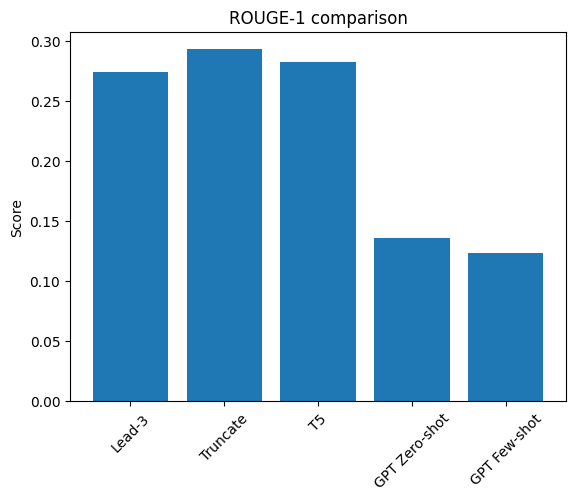

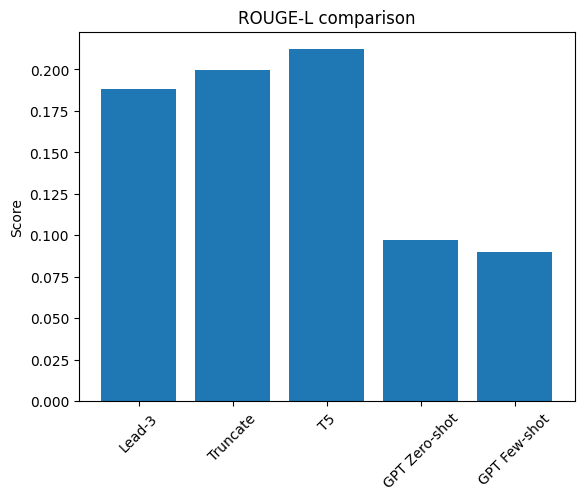

In [56]:
# Visualization

plt.figure()
plt.bar(results_df["Model"], results_df["ROUGE-1"])
plt.xticks(rotation=45)
plt.title("ROUGE-1 comparison")
plt.ylabel("Score")
plt.show()

plt.figure()
plt.bar(results_df["Model"], results_df["ROUGE-L"])
plt.xticks(rotation=45)
plt.title("ROUGE-L comparison")
plt.ylabel("Score")
plt.show()

Some results:

* T5 outperforms GPT2 in all the metrics; this is expected, as T5 is trained on such task. GPT2 fails when it has to follow a specific task.
* T5 has a ROUGE-1 similar to the baseline models and a slightly better ROUGE-L. T5 doesn't copy, but reformulate the text, that's why the overlap with the text is smaller (smaller ROUGE-1), but the structure is better (higher ROUGE-L).
* Truncation has the best ROUGE-1 score, but it doesn't really make a summarization. This is a limit of the ROUGE score.
* These results show a trade-off between extractive and abstractive summarization; extractive methods (truncation) achieve higher overlap, and abstractive ones (T5) produce more meaningful summarizations.